In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm
#import contextily as ctxv
import osmnx as ox
from osmnx import graph_to_gdfs
from shapely.ops import unary_union
from shapely.geometry import MultiPoint
import logging 
import pickle
ox.settings.log_console = True

In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.optim as optim

In [3]:
df = pd.read_parquet("huge.parquet")

In [1]:
import pyarrow.parquet as pq
import pandas as pd

def read_parquet_in_rowgroups(path, columns=None):
    pf = pq.ParquetFile(path)
    parts = []
    for rg in range(pf.num_row_groups):
        tbl = pf.read_row_group(rg, columns=columns)
        parts.append(tbl.to_pandas())
    return pd.concat(parts, ignore_index=True)

# Only pull in the vector columns (drop geometry if you don’t need it)
cols = [c for c in pq.ParquetFile("POI_vec_proj_matrix.parquet").schema.names
        if c not in ("geometry",)]
vec_proj_matrix = read_parquet_in_rowgroups(
    "POI_vec_proj_matrix.parquet",
    columns=cols
)

In [5]:
df.head
from shapely import wkb
df['geometry'] = df['geometry'].apply(wkb.loads)
df['centroid'] = df['centroid'].apply(wkb.loads)


In [6]:
feature_dict = {}
for traj_id, group in df.groupby('traj_id'):
    # sort by time
    grp = group.sort_values('pt_idx')
    embs = np.stack(grp['embedding'].values)    # shape (L, E)
    vecs = np.stack(grp['vec_mean'].values)     # shape (L, V)
    feature_dict[traj_id] = np.concatenate([embs, vecs], axis=1)  # (L, E+V)

In [7]:
feature_dict["0000a204849023cd902b8c7dd9edc37b8bbc222edbe6620b26b852a3e24b317c"][12]

array([ 0.61712062, -0.281688  , -0.83508587, ..., -1.55975747,
        1.23561358, -1.23357332])

In [8]:
class TrajDataset(Dataset):
    def __init__(self, feature_dict):
        self.ids = list(feature_dict.keys())
        self.feature_dict = feature_dict

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        feat = torch.from_numpy(self.feature_dict[self.ids[i]]).float()
        length = feat.size(0)
        return feat, length

def collate_fn(batch):
    # batch: list of (feat_tensor[L×D], length) tuples
    feats, lengths = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.long)
    # pad to max length in batch
    padded = pad_sequence(feats, batch_first=True)  
    # padded.shape = (B, L_max, D)
    return padded, lengths

# instantiate
ds = TrajDataset(feature_dict)
loader = DataLoader(ds, batch_size=64, shuffle=True, 
                    collate_fn=collate_fn, drop_last=True)

In [9]:
class TrajAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32, num_layers=1):
        super().__init__()
        # — encoder —
        # input_size = input_dim, hidden_size = hidden_dim (per direction)
        self.encoder = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        # 2*hidden_dim → latent
        self.to_latent = nn.Linear(2*hidden_dim, latent_dim)

        # — decoder initial state from latent —
        # latent → 2*hidden_dim (for h), we’ll split for (h, c) below
        self.from_latent = nn.Linear(latent_dim, 2*hidden_dim)

        # — decoder LSTM —
        # input_size = input_dim (we feed zero-vectors of that size)
        # hidden_size = 2*hidden_dim (so h/c match from_latent output)
        self.decoder = nn.LSTM(
            input_dim, 2*hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # — final projection back to input_dim —
        self.output_layer = nn.Linear(2*hidden_dim, input_dim)

    def forward(self, x, lengths):
        # x: (B, L, D=input_dim), lengths: cpu-tensor of shape (B,)
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, (hn, cn) = self.encoder(packed)
        # hn: (num_layers*2, B, hidden_dim)
        # grab the last layer’s fwd+back states
        h_fwd = hn[-2]  # (B, hidden_dim)
        h_bwd = hn[-1]  # (B, hidden_dim)
        h = torch.cat([h_fwd, h_bwd], dim=1)  # (B, 2*hidden_dim)

        # latent code
        z = self.to_latent(h)  # (B, latent_dim)

        # prepare decoder hidden/cell
        h_dec = self.from_latent(z).unsqueeze(0)      # (1, B, 2*hidden_dim)
        c_dec = torch.zeros_like(h_dec)               # same shape

        # decoder input: all‐zero sequence
        B, L, D = x.size()
        dec_in = torch.zeros(B, L, D, device=x.device)

        # run LSTM
        dec_out, _ = self.decoder(dec_in, (h_dec, c_dec))
        # project each hidden vector back to dimension D
        recon = self.output_layer(dec_out)  # (B, L, D)

        return recon, z


In [10]:

"""first = df.iloc[0]
emb_dim = first['embedding'].shape[0]   # E
vec_dim = first['vec_mean'].shape[0]  
model = TrajAutoencoder(input_dim=emb_dim+vec_dim).cuda()
opt   = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='none')

for epoch in range(20):
    model.train()
    total_loss = 0
    for x, lengths in loader:
        x = x.cuda()             # good: inputs on GPU
        # lengths stays on the CPU
        recon, z = model(x, lengths)
        
        # if you need lengths on the GPU for masking:
        lengths_gpu = lengths.to(x.device)
        mask = (
          torch.arange(x.size(1), device=x.device)[None]
          < lengths_gpu[:, None]
        )
        loss = criterion(recon, x).mean(dim=2)  # (B, L)
        loss = (loss * mask.float()).sum() / mask.sum()

        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:02d}  recon_loss = {total_loss/len(loader):.4f}")
"""

'first = df.iloc[0]\nemb_dim = first[\'embedding\'].shape[0]   # E\nvec_dim = first[\'vec_mean\'].shape[0]  \nmodel = TrajAutoencoder(input_dim=emb_dim+vec_dim).cuda()\nopt   = optim.Adam(model.parameters(), lr=1e-3)\ncriterion = nn.MSELoss(reduction=\'none\')\n\nfor epoch in range(20):\n    model.train()\n    total_loss = 0\n    for x, lengths in loader:\n        x = x.cuda()             # good: inputs on GPU\n        # lengths stays on the CPU\n        recon, z = model(x, lengths)\n\n        # if you need lengths on the GPU for masking:\n        lengths_gpu = lengths.to(x.device)\n        mask = (\n          torch.arange(x.size(1), device=x.device)[None]\n          < lengths_gpu[:, None]\n        )\n        loss = criterion(recon, x).mean(dim=2)  # (B, L)\n        loss = (loss * mask.float()).sum() / mask.sum()\n\n        opt.zero_grad()\n        loss.backward()\n        opt.step()\n        total_loss += loss.item()\n    print(f"Epoch {epoch:02d}  recon_loss = {total_loss/len(loader)

In [11]:
#orch.save({
#    "epoch": epoch,
#    "model_state_dict": model.state_dict(),
#    "optim_state_dict": opt.state_dict(),
#    "loss": total_loss,
#}, "traj_autoencoder_checkpoint.pt")
first = df.iloc[0]
emb_dim = first['embedding'].shape[0]   # E
vec_dim = first['vec_mean'].shape[0]  
device = "cuda"
# ── Later, to resume training ───────────────────────────────────────────────────
checkpoint = torch.load("traj_autoencoder_checkpoint.pt", map_location=device)
model = TrajAutoencoder(input_dim=emb_dim + vec_dim)
opt   = optim.Adam(model.parameters(), lr=1e-3)

model.load_state_dict(checkpoint["model_state_dict"])
opt.load_state_dict(checkpoint["optim_state_dict"])
start_epoch = checkpoint["epoch"] + 1

model.to(device)

TrajAutoencoder(
  (encoder): LSTM(1280, 128, batch_first=True, bidirectional=True)
  (to_latent): Linear(in_features=256, out_features=32, bias=True)
  (from_latent): Linear(in_features=32, out_features=256, bias=True)
  (decoder): LSTM(1280, 256, batch_first=True)
  (output_layer): Linear(in_features=256, out_features=1280, bias=True)
)

In [12]:
model.eval()
zs = []
with torch.no_grad():
    for x, lengths in loader:
        x = x.cuda()           # only move the data
        # leave `lengths` on CPU (int64), as required by pack_padded_sequence
        _, z = model(x, lengths)
        zs.append(z.cpu())

Z = torch.cat(zs, dim=0).numpy()
# clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(Z)
labels = kmeans.labels_  # one label per traj

# map back to traj_ids
traj_ids = ds.ids[: len(labels) ]
cluster_df = pd.DataFrame({'traj_id': traj_ids, 'cluster': labels})

In [13]:
cluster_df = pd.read_csv("clustered_result.csv")

In [14]:
hex_gdf = pd.read_parquet("Hex_tesse_raw.parquet")
hex_gdf = hex_gdf.reset_index(drop=True)  

# 2) Create a hex_id column (string or integer) from that index.
hex_gdf["hex_id"] = hex_gdf.index.astype(str)
hex_gdf["geometry"] = gpd.GeoSeries.from_wkb(hex_gdf["geometry"])
# Now convert to a GeoDataFrame:
hex_gdf = gpd.GeoDataFrame(hex_gdf, geometry="geometry", crs="EPSG:4326")

In [15]:
cleaned_df = df.copy()

In [16]:
hex_gdf = hex_gdf.set_crs(epsg=4326, allow_override=True)

# 2) reproject to an equal‐area CRS
hex_aea = hex_gdf.to_crs(epsg=5070)

# 3) compute true planar centroids
hex_aea['centroid_proj'] = hex_aea.geometry.centroid

# 4) extract X/Y in projected units if you need them:
hex_aea['centroid_x_proj'] = hex_aea.centroid_proj.x
hex_aea['centroid_y_proj'] = hex_aea.centroid_proj.y

# 5) if you still want lon/lat centroids, reproject back
centroids_ll = hex_aea.centroid_proj.to_crs(epsg=4326)
hex_gdf['centroid']   = centroids_ll
hex_gdf['centroid_x'] = centroids_ll.x
hex_gdf['centroid_y'] = centroids_ll.y

In [17]:
states = gpd.read_file('cb_2018_us_state_500k.shp')


In [18]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# ── 0) Utility to pick top‐m trajectories per cluster by proximity in Z-space
def find_representative_trajectories(Z, labels, traj_ids, centers, m=50):
    reps = {}
    K = centers.shape[0]
    for c in range(K):
        idx_c = np.where(labels == c)[0]          # indices in Z for cluster c
        Zc    = Z[idx_c]                          # their latent vectors
        # Euclidean distance to cluster centroid
        dists = np.linalg.norm(Zc - centers[c], axis=1)
        # pick the m smallest distances
        order = np.argsort(dists)[: min(m, len(dists))]
        reps[c] = [traj_ids[i] for i in idx_c[order]]
    return reps
m = 10
# ── 1) Compute representatives (50 per cluster)
#    MAKE SURE Z, labels, ds.ids, and kmeans.cluster_centers_ are in scope
representatives = find_representative_trajectories(
    Z, labels, ds.ids, kmeans.cluster_centers_, m
)

# ── 2) Merge cluster labels into your point‐level table
joined = cleaned_df.merge(cluster_df, on="traj_id", how="left")

# ── 3) Build LineStrings for the representative traj_ids
traj_lines = []
for cl, tid_list in representatives.items():
    for tid in tid_list:
        sub = joined[joined["traj_id"] == tid].sort_values("pt_idx")
        pts = [
            hex_gdf.at[int(h), "centroid"]
            for h in sub["index_right"].dropna().astype(int)
        ]
        if len(pts) >= 2:
            traj_lines.append({
                "traj_id": tid,
                "cluster": cl,
                "geometry": LineString(pts)
            })

traj_lines_gdf = gpd.GeoDataFrame(
    traj_lines,
    geometry="geometry",
    crs=hex_gdf.crs
)

# ── 4) Prepare output folder
out_dir = "cluster_results"
os.makedirs(out_dir, exist_ok=True)

# ── 5) Color mapping (rainbow per cluster)
cluster_ids = sorted(traj_lines_gdf['cluster'].unique())
colors = plt.cm.rainbow(np.linspace(0, 1, len(cluster_ids)))
color_map = dict(zip(cluster_ids, colors))

# ── 6) Loop and save each cluster’s representative‐only plot
for cl in cluster_ids:
    fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

    # Florida boundary
    states[states.STUSPS == "FL"].boundary.plot(
        ax=ax, linewidth=1, color="black"
    )

    # Representative trajectories for this cluster
    subset = traj_lines_gdf[traj_lines_gdf['cluster'] == cl]
    subset.plot(
        ax=ax,
        color=color_map[cl],
        linewidth=1.5
    )

    ax.set_title(f"Cluster {cl} — Top 50 Representatives", fontsize=20)
    ax.set_axis_off()

    fname = os.path.join(out_dir, f"cluster_{cl}_repr{m}.png")
    fig.savefig(fname, bbox_inches='tight')
    plt.close(fig)

    print(f"→ Saved Cluster {cl} representatives: {fname}")


→ Saved Cluster 0 representatives: cluster_results/cluster_0_repr10.png
→ Saved Cluster 1 representatives: cluster_results/cluster_1_repr10.png
→ Saved Cluster 2 representatives: cluster_results/cluster_2_repr10.png
→ Saved Cluster 3 representatives: cluster_results/cluster_3_repr10.png
→ Saved Cluster 4 representatives: cluster_results/cluster_4_repr10.png


In [19]:
vec_proj_matrix

,concatenated,REGION,LOCATION_NAME,concatenated_vec
0,Activities Related to Real Estate[sep]Resident...,FL,Jeffrey Berg,[-3.41533518e+00 -1.49931777e+00 1.36452806e+...
1,Offices of Real Estate Agents and Brokers[sep]...,FL,Search Beacon Realty,[-2.38089347e+00 2.18140173e+00 -8.13243628e-...
2,"Sporting Goods, Hobby, and Musical Instrument ...",FL,Bone Island Music Key West,[ 5.42108893e-01 1.63252306e+00 -1.99507982e-...
3,Offices of Dentists[sep]Offices of Dentists[se...,FL,Dr. Arbel Maghsoodpour DDS,[-3.0437524e+00 -1.1710362e+00 6.8726033e-01 ...
4,"Museums, Historical Sites, and Similar Institu...",FL,Roberto Clemente Park,[ 2.64899683e+00 4.96178687e-01 -9.97523606e-...
...,...,...,...,...
1548012,Home Furnishings Stores[sep]All Other Home Fur...,FL,FL Custom Kitchen and Baths,[ 5.19509935e+00 -3.56546664e+00 1.36108625e+...
1548013,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Cedar Highlands & Jimmy Ann Ib,[ 2.06519341e+00 -2.15121603e+00 1.27448708e-...
1548014,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Plymouth & 15a Ib,[ 2.22038412e+00 -8.90327156e-01 4.48130012e-...
1548015,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Zelda & A1a Ib,[ 7.69490540e-01 -3.18823189e-01 3.16257668e+...


In [20]:
cluster_df

,Unnamed: 0,traj_id,cluster
0,0,0000a204849023cd902b8c7dd9edc37b8bbc222edbe662...,1
1,1,0000a70c6bce971755183b6155d263a1db3027e6ead671...,2
2,2,0000d1f90748a756d45a2c6ac8489bb6db9c9bfa96c1d2...,2
3,3,0001cb486921957ec892d0d3ab7f13e22926223e16518e...,4
4,4,0001e79f8ecb5fd97d9ef38485f2dad1fe7438b0e00528...,1
...,...,...,...
95355,95355,ffd5a2c5ff39748ee9d6a7b832d5d80d99bdbff4587499...,3
95356,95356,ffd6849bd1179a638da31eb7590a520b58768eb5f72b26...,2
95357,95357,ffd9f1ad2f965dabfadaff20399b314ca48854d93f26e8...,2
95358,95358,ffdaaf768a99e1b202524a54e72eb7eeb85efd0b577548...,1


In [21]:
hex_gdf

,geometry,hex_id,centroid,centroid_x,centroid_y
0,"POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...",0,POINT (-81.80131 24.45615),-81.801311,24.456155
1,"POLYGON ((-81.795 24.45908, -81.79236 24.45908...",1,POINT (-81.79504 24.45748),-81.795042,24.457484
2,"POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...",2,POINT (-81.80955 24.47009),-81.809553,24.470090
3,"POLYGON ((-81.7925 24.45908, -81.8025 24.45908...",3,POINT (-81.7975 24.46774),-81.797500,24.467741
4,"POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...",4,POINT (-81.78502 24.47073),-81.785019,24.470732
...,...,...,...,...,...
74746,"POLYGON ((-86.09 32.33991, -86.1 32.33991, -86...",74746,POINT (-86.09502 32.34136),-86.095023,32.341364
74747,"POLYGON ((-86.075 32.33991, -86.085 32.33991, ...",74747,POINT (-86.08002 32.34133),-86.080023,32.341332
74748,"POLYGON ((-86.06 32.33991, -86.07 32.33991, -8...",74748,POINT (-86.06502 32.3413),-86.065023,32.341301
74749,"POLYGON ((-86.045 32.33991, -86.055 32.33991, ...",74749,POINT (-86.05002 32.34127),-86.050023,32.341270


In [22]:
cleaned_df

,traj_id,pt_idx,geometry,index_right,vec_mean,embedding,centroid
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,POINT (-81.796707 24.548311999999992),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365)
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,POINT (-81.796739 24.54832400000003),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365)
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,POINT (-81.796648 24.54830700000004),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365)
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,POINT (-81.949365 26.45100899999995),8332,"[0.43893394, -1.1964977, 0.27314708, -0.739029...","[-0.1845903992652893, -0.3903314173221588, -0....",POINT (-81.9475000000363 26.44227875184205)
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,POINT (-81.949299 26.451006999999986),8332,"[0.43893394, -1.1964977, 0.27314708, -0.739029...","[-0.1845903992652893, -0.3903314173221588, -0....",POINT (-81.9475000000363 26.44227875184205)
...,...,...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,POINT (-81.504768 29.942492000000026),41486,"[0.98221266, -0.14179757, 0.25806758, -0.72663...","[-0.40670105814933777, 0.23767414689064026, 0....",POINT (-81.51249999996638 29.94102134001624)
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,POINT (-81.5499999823643 30.080000043115593),43489,"[0.36733067, 0.16317618, 0.08410208, -0.859154...","[-0.2411247342824936, 0.3367861211299896, 0.10...",POINT (-81.55749998138191 30.079585446531212)
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,POINT (-81.5499999823643 30.080000043115593),43489,"[0.36733067, 0.16317618, 0.08410208, -0.859154...","[-0.2411247342824936, 0.3367861211299896, 0.10...",POINT (-81.55749998138191 30.079585446531212)
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,POINT (-81.51031 29.944345000000062),41486,"[0.98221266, -0.14179757, 0.25806758, -0.72663...","[-0.40670105814933777, 0.23767414689064026, 0....",POINT (-81.51249999996638 29.94102134001624)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
# 4) Move to GPU/CPU and set eval mode:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) Where you saved your LoRA adapters after training:
CHECKPOINT = "/storage1/fs1/nlin/Active/sizhe/FO_DATA/checkpoint-dir/checkpoint-551"

# 2) Load the tokenizer from that folder (it contains tokenizer.json + vocab.txt)
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

base_name = "google/gemma-3-1b-it"     # <— exactly what you passed in your training script
base = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-it",
    attn_implementation="eager"
).to(device)

# 3) Now graft the adapter weights:
model = PeftModel.from_pretrained(base, CHECKPOINT)


model.to(device).eval()

In [24]:
def embed_texts(texts: list[str]) -> torch.Tensor:
    """
    texts: a Python list of strings (each may contain literal "[sep]").
    example: ["[Museums, Historical Sites,...<sep>Museums, Historical Sites<sep>Natural History museum]",...]
    In the format of [<category><sep><subcategory><sep><name>]
    Returns: a GPU tensor of shape (len(texts), hidden_size) containing the
             final‐token embedding for each string.
    """
    # 2.1) Clean & force everything to str, replacing None/NaN with ""
    clean_texts=[]
    for t in texts:
        if t is None:
            clean_texts.append("")
        else:
            clean_texts.append(str(t))
    sep = tokenizer.sep_token  # e.g. "[SEP]" for BERT‐style; whatever your tokenizer.sep_token is
    clean_texts = [t.replace("[sep]", sep) for t in clean_texts]
    
    # 2.3) Batch‐tokenize all strings onto GPU
    enc = tokenizer(
        clean_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
        return_token_type_ids=False,
    ).to(device)
    #print("Batch input_ids are on:", enc.input_ids.device)
    # Now enc.input_ids and enc.attention_mask live on GPU.

    # 2.4) Forward‐pass (no gradients) to get hidden states
    with torch.no_grad():
        outputs = model.base_model(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
            output_hidden_states=True
        )
        # `outputs.hidden_states` is a tuple of length (num_layers+1);
        # each element has shape (batch_size, seq_len, hidden_size).
        last_hidden = outputs.hidden_states[-1]  # (batch_size, seq_len, hidden_size) on GPU

    # 2.5) For each sequence, pick out the final non‐pad token embedding
    seq_lens = enc.attention_mask.sum(dim=1) - 1  # (batch_size,) on GPU, index of last non-pad
    batch_size, hidden_size = last_hidden.size(0), last_hidden.size(2)

    # Gather the embedding at position (i, seq_lens[i], :)
    final_embs = last_hidden[torch.arange(batch_size), seq_lens, :]  # (batch_size, hidden_size) on GPU
    #print((final_embs))
    return final_embs


In [25]:
cat_embs.shape

NameError: name 'cat_embs' is not defined

In [ ]:
(cat_dist_df)

In [ ]:
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────────────────────────
# (A) Build & parse your unique category–subcategory strings
# ────────────────────────────────────────────────────────────────────────────────
sep       = "[sep]"
full_txts = vec_proj_matrix["concatenated"].astype(str).tolist()
cs_txts   = ["[sep]".join(s.split(sep)[:2]) for s in full_txts]

seen = {}
unique_cs = []
for txt in cs_txts:
    if txt not in seen:
        seen[txt] = True
        unique_cs.append(txt)

cs_cats    = [txt.split(sep)[0] for txt in unique_cs]
cs_subcats = [txt.split(sep)[1] for txt in unique_cs]

# ────────────────────────────────────────────────────────────────────────────────
# (B) Embed all cat–subcat strings (raw), move to numpy
# ────────────────────────────────────────────────────────────────────────────────
cat_embs    = embed_texts(unique_cs)              # (C, H) on GPU
cs_embs_np  = cat_embs.cpu().numpy()              # (C, H)

# ────────────────────────────────────────────────────────────────────────────────
# (C) Compute the covariance & its inverse (Mahalanobis)
# ────────────────────────────────────────────────────────────────────────────────
# 1) covariance of the category embeddings (H×H)
cov = np.cov(cs_embs_np, rowvar=False)

# 2) regularize & invert
eps    = 1e-6
inv_cov = np.linalg.inv(cov + eps * np.eye(cov.shape[0]))  # (H, H)

# ────────────────────────────────────────────────────────────────────────────────
# (D) Prepare your merged df (cluster, pt_idx, vec_mean)
# ────────────────────────────────────────────────────────────────────────────────
df = (
    cleaned_df
    .merge(cluster_df, on="traj_id", how="inner")
    [["cluster", "pt_idx", "vec_mean"]]
)

# ────────────────────────────────────────────────────────────────────────────────
# (E) Loop over each (cluster, pt_idx) and pick the nearest by Mahalanobis
# ────────────────────────────────────────────────────────────────────────────────
records = []
for (cluster_id, t), group in df.groupby(["cluster","pt_idx"]):
    M   = np.vstack(group["vec_mean"].tolist())  # (n_pts, H)
    avg = M.mean(axis=0)                         # (H,)

    # compute Mahalanobis distances to all C embeddings
    diffs = cs_embs_np - avg[None, :]            # (C, H)
    left  = diffs @ inv_cov                       # (C, H)
    dists = np.sqrt(np.einsum("ij,ij->i", left, diffs))  # (C,)

    best_i = int(np.argmin(dists))
    records.append({
        "cluster":      cluster_id,
        "pt_idx":       t,
        "category":     cs_cats[best_i],
        "subcategory":  cs_subcats[best_i],
        "maha_dist":    float(dists[best_i]),
    })

top1_maha = pd.DataFrame.from_records(records)

# ────────────────────────────────────────────────────────────────────────────────
# (F) Merge back onto your original df
# ────────────────────────────────────────────────────────────────────────────────
df = df.merge(top1_maha, on=["cluster","pt_idx"], how="left")

print(df.shape)
df.head(20)


In [ ]:
df

In [31]:
import numpy as np
import faiss
import pandas as pd
import torch

# ────────────────────────────────────────────────────────────────────────────────
# 1) Build & normalize your C×H category–subcategory embeddings
# ────────────────────────────────────────────────────────────────────────────────
sep      = "[sep]"
null_val = "<null_val>"

# full_txts is your list of "[cat][sep][subcat][sep][name]" strings
cs_txts = [
    sep.join(s.split(sep)[:2] + [null_val])
    for s in full_txts
]
# dedupe
seen      = set()
unique_cs = []
for txt in cs_txts:
    if txt not in seen:
        seen.add(txt)
        unique_cs.append(txt)

cs_cats    = [txt.split(sep)[0] for txt in unique_cs]
cs_subcats = [txt.split(sep)[1] for txt in unique_cs]

# embed on GPU (C, H)
cat_embs = embed_texts(unique_cs)

# normalize to unit‐vectors
cat_embs = cat_embs / cat_embs.norm(dim=1, keepdim=True)

# move to CPU float32
cs_embs_np = cat_embs.cpu().numpy().astype("float32")  # shape (C, H)

# ────────────────────────────────────────────────────────────────────────────────
# 2) Build a Faiss inner‐product index (cosine on unit‐vectors)
# ────────────────────────────────────────────────────────────────────────────────
d = cs_embs_np.shape[1]
index = faiss.IndexFlatIP(d)
index.add(cs_embs_np)   # loads ~C×H×4 bytes

# ────────────────────────────────────────────────────────────────────────────────
# 3) In batches, normalize cleaned_df.vec_mean → query the index
# ────────────────────────────────────────────────────────────────────────────────
N = len(cleaned_df)
batch_size = 50_000

cat_out = [None]*N
sub_out = [None]*N
sim_out = [None]*N

for start in range(0, N, batch_size):
    end = min(start + batch_size, N)
    block = np.vstack(cleaned_df["vec_mean"].iloc[start:end].tolist()).astype("float32")  # (B, H)
    norms = np.linalg.norm(block, axis=1, keepdims=True)
    block_norm = block / norms  # unit‐length rows, (B, H)

    # inner product search → gives cosine similarity on unit‐vectors
    sims, idxs = index.search(block_norm, 1)  # (B,1), (B,1)
    for i, (sim, idx) in enumerate(zip(sims[:,0], idxs[:,0])):
        cat_out[start + i] = cs_cats[idx]
        sub_out[start + i] = cs_subcats[idx]
        sim_out[start + i] = float(sim)

# ────────────────────────────────────────────────────────────────────────────────
# 4) Attach back to cleaned_df
# ────────────────────────────────────────────────────────────────────────────────
cleaned_df["category"]     = cat_out
cleaned_df["subcategory"]  = sub_out
cleaned_df["cosine_sim"]   = sim_out

# Quick check
print(cleaned_df[["category","subcategory","cosine_sim"]].head())


                                            category  \
0  Electronic and Precision Equipment Repair and ...   
1  Electronic and Precision Equipment Repair and ...   
2  Electronic and Precision Equipment Repair and ...   
3  Electronic and Precision Equipment Repair and ...   
4  Electronic and Precision Equipment Repair and ...   

                                         subcategory  cosine_sim  
0  Other Electronic and Precision Equipment Repai...    0.919599  
1  Other Electronic and Precision Equipment Repai...    0.919599  
2  Other Electronic and Precision Equipment Repai...    0.919599  
3  Other Electronic and Precision Equipment Repai...    0.892689  
4  Other Electronic and Precision Equipment Repai...    0.892689  


In [32]:
cleaned_df

,traj_id,pt_idx,geometry,index_right,vec_mean,embedding,centroid,category,subcategory,maha_dist,cosine_sim
0,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,1,POINT (-81.796707 24.548311999999992),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365),Electronic and Precision Equipment Repair and ...,Other Electronic and Precision Equipment Repai...,9370544.0,0.919599
1,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,3,POINT (-81.796739 24.54832400000003),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365),Electronic and Precision Equipment Repair and ...,Other Electronic and Precision Equipment Repai...,9370544.0,0.919599
2,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,5,POINT (-81.796648 24.54830700000004),48,"[0.53333396, -0.6309159, 0.4254715, -0.6440962...","[-0.6102308034896851, -0.023300886154174805, -...",POINT (-81.78999999997579 24.55434339401365),Electronic and Precision Equipment Repair and ...,Other Electronic and Precision Equipment Repai...,9370544.0,0.919599
3,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,20,POINT (-81.949365 26.45100899999995),8332,"[0.43893394, -1.1964977, 0.27314708, -0.739029...","[-0.1845903992652893, -0.3903314173221588, -0....",POINT (-81.9475000000363 26.44227875184205),Electronic and Precision Equipment Repair and ...,Other Electronic and Precision Equipment Repai...,19445264.0,0.892689
4,e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...,21,POINT (-81.949299 26.451006999999986),8332,"[0.43893394, -1.1964977, 0.27314708, -0.739029...","[-0.1845903992652893, -0.3903314173221588, -0....",POINT (-81.9475000000363 26.44227875184205),Electronic and Precision Equipment Repair and ...,Other Electronic and Precision Equipment Repai...,19445264.0,0.892689
...,...,...,...,...,...,...,...,...,...,...,...
1677305,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,130,POINT (-81.504768 29.942492000000026),41486,"[0.98221266, -0.14179757, 0.25806758, -0.72663...","[-0.40670105814933777, 0.23767414689064026, 0....",POINT (-81.51249999996638 29.94102134001624),Offices of Other Health Practitioners,Offices of Chiropractors,31177008.0,0.912280
1677306,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,133,POINT (-81.5499999823643 30.080000043115593),43489,"[0.36733067, 0.16317618, 0.08410208, -0.859154...","[-0.2411247342824936, 0.3367861211299896, 0.10...",POINT (-81.55749998138191 30.079585446531212),Offices of Other Health Practitioners,Offices of Chiropractors,12022456.0,0.914177
1677307,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,134,POINT (-81.5499999823643 30.080000043115593),43489,"[0.36733067, 0.16317618, 0.08410208, -0.859154...","[-0.2411247342824936, 0.3367861211299896, 0.10...",POINT (-81.55749998138191 30.079585446531212),Offices of Other Health Practitioners,Offices of Chiropractors,12022456.0,0.914177
1677308,559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...,140,POINT (-81.51031 29.944345000000062),41486,"[0.98221266, -0.14179757, 0.25806758, -0.72663...","[-0.40670105814933777, 0.23767414689064026, 0....",POINT (-81.51249999996638 29.94102134001624),Offices of Other Health Practitioners,Offices of Chiropractors,31177008.0,0.912280


In [34]:
hex_only = cleaned_df.drop_duplicates(subset=["index_right"])

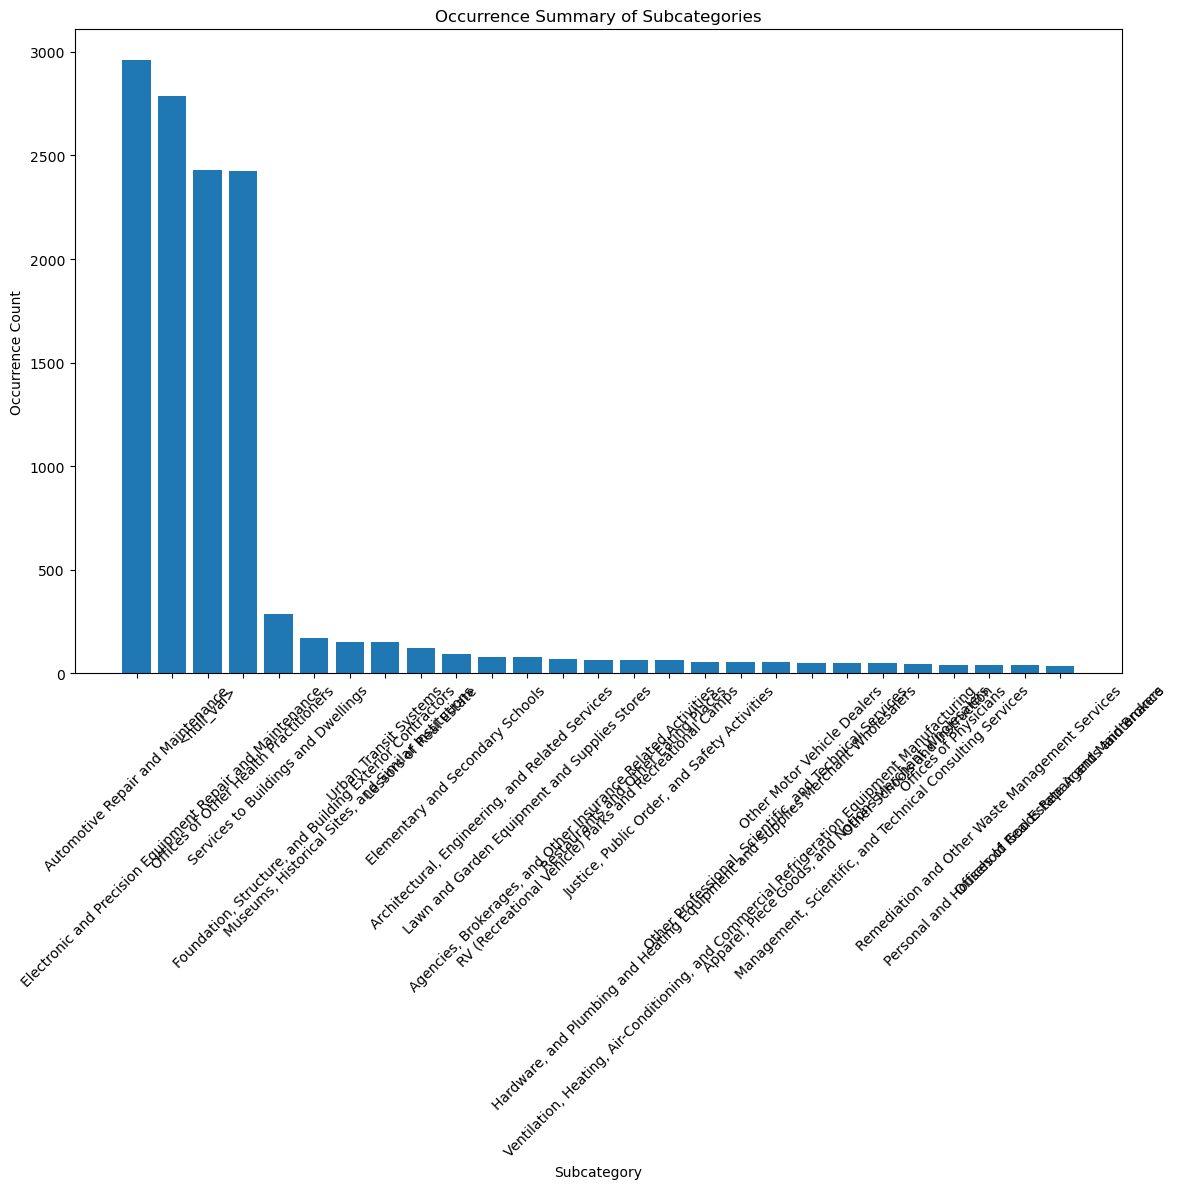

In [43]:
import matplotlib.pyplot as plt

# Count occurrences of each subcategory
# 1. get the counts per category
counts = hex_only['category'].value_counts()

# 2. map those counts back onto each row, then threshold
row_mask = hex_only['category'].map(counts) > 30

# 3. filter
filtered = hex_only[row_mask]
counts = filtered['category'].value_counts()
# Plot bar chart
fig, ax = plt.subplots(figsize=(12, 12))
ax.bar(range(len(counts)), counts.values)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45)
ax.set_ylabel('Occurrence Count')
ax.set_xlabel('Subcategory')
ax.set_title('Occurrence Summary of Subcategories')
plt.tight_layout()
plt.show()